In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

In [4]:
soccer = pd.read_csv('../output/csvs/soccer_generalized_cscores.csv')
soccer

,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,n1*,c1*,n2*,c2*
0,Bundesliga,2000,Bayern Munich,"[1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, ...",28,14,14,19,9,10,1.414208,1.521762,1.233046,10,2.449470,10.0,3.944894
1,Bundesliga,2000,Bochum,"[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...",28,14,14,7,5,2,3.557103,10.502532,4.975124,5,4.213992,5.0,12.959781
2,Bundesliga,2000,Cottbus,"[0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, ...",31,16,15,12,6,6,1.540103,1.796042,1.443001,13,1.633396,13.0,2.039216
3,Bundesliga,2000,Dortmund,"[1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",24,12,12,16,7,9,1.221184,1.239523,1.118568,8,1.880482,5.0,2.768998
4,Bundesliga,2000,Ein Frankfurt,"[1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, ...",29,15,14,10,6,4,2.278359,3.863890,2.433090,10,3.663872,10.0,8.551127
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1433,La_Liga,2024,Sociedad,"[0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, ...",31,16,15,13,8,5,2.899686,5.758226,3.367003,6,4.892563,6.0,12.309017
1434,La_Liga,2024,Valencia,"[0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, ...",25,13,12,11,3,8,1.031319,1.014335,1.003009,2,3.188776,2.0,10.458316
1435,La_Liga,2024,Valladolid,"[1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ...",34,17,17,4,4,0,8.396151,60.167004,19.872814,17,8.396151,17.0,60.167004
1436,La_Liga,2024,Vallecano,"[1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",25,13,12,13,7,6,1.793021,2.359879,1.686341,10,3.041173,10.0,6.119959


In [5]:
us_leagues = pd.read_csv('../output/csvs/us_generalized_cscores.csv')
us_leagues

,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,n1*,c1*,n2*,c2*
0,NBA,2015,Orlando Magic,"[0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, ...",82,41,41,35,20,15,3.764011,7.567749,5.617978,41,3.764011,41,7.567749
1,NBA,2015,Houston Rockets,"[0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, ...",82,41,41,41,21,20,2.000000,2.423658,2.057613,35,2.717839,35,3.976260
2,NBA,2015,Oklahoma City Thunder,"[1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, ...",82,41,41,55,29,26,2.749747,4.159434,3.300330,8,11.926959,8,32.797102
3,NBA,2015,Sacramento Kings,"[0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, ...",82,41,41,33,18,15,2.639310,4.005520,3.105590,39,4.190481,39,8.918303
4,NBA,2015,Utah Jazz,"[0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, ...",82,41,41,40,18,22,1.277825,1.232172,1.136364,5,4.923305,2,12.320543
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4318,NBA,1982,Indiana Pacers,"[1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, ...",82,41,41,20,13,7,5.464184,16.280440,9.009009,37,12.046809,37,53.259359
4319,NBA,1982,Washington Bullets,"[0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, ...",82,41,41,42,18,24,1.158671,1.101917,1.064963,3,2.075934,1,6.610688
4320,NBA,1982,Dallas Mavericks,"[1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, ...",82,41,41,38,19,19,1.774389,2.000000,1.808318,11,18.279912,11,45.312997
4321,NBA,1982,Denver Nuggets,"[0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, ...",82,41,41,45,19,26,1.115894,1.064008,1.047120,15,1.812723,15,2.236664


In [6]:
soccer['n2*'].value_counts().reset_index()

,n2*,count
0,1.0,239
1,2.0,170
2,3.0,122
3,6.0,94
4,7.0,94
5,5.0,91
6,4.0,90
7,8.0,87
8,9.0,79
9,11.0,79


In [7]:
soccer['normalized_n2*'] = soccer['n2*']/soccer['n']
soccer

,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,n1*,c1*,n2*,c2*,normalized_n2*
0,Bundesliga,2000,Bayern Munich,"[1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, ...",28,14,14,19,9,10,1.414208,1.521762,1.233046,10,2.449470,10.0,3.944894,0.357143
1,Bundesliga,2000,Bochum,"[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...",28,14,14,7,5,2,3.557103,10.502532,4.975124,5,4.213992,5.0,12.959781,0.178571
2,Bundesliga,2000,Cottbus,"[0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, ...",31,16,15,12,6,6,1.540103,1.796042,1.443001,13,1.633396,13.0,2.039216,0.419355
3,Bundesliga,2000,Dortmund,"[1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",24,12,12,16,7,9,1.221184,1.239523,1.118568,8,1.880482,5.0,2.768998,0.208333
4,Bundesliga,2000,Ein Frankfurt,"[1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, ...",29,15,14,10,6,4,2.278359,3.863890,2.433090,10,3.663872,10.0,8.551127,0.344828
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1433,La_Liga,2024,Sociedad,"[0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, ...",31,16,15,13,8,5,2.899686,5.758226,3.367003,6,4.892563,6.0,12.309017,0.193548
1434,La_Liga,2024,Valencia,"[0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, ...",25,13,12,11,3,8,1.031319,1.014335,1.003009,2,3.188776,2.0,10.458316,0.080000
1435,La_Liga,2024,Valladolid,"[1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ...",34,17,17,4,4,0,8.396151,60.167004,19.872814,17,8.396151,17.0,60.167004,0.500000
1436,La_Liga,2024,Vallecano,"[1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",25,13,12,13,7,6,1.793021,2.359879,1.686341,10,3.041173,10.0,6.119959,0.400000


In [8]:
soccer['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,1433.000000
1,mean,0.229465
2,std,0.155140
3,min,0.027778
4,25%,0.080000
5,50%,0.206897
6,75%,0.370370
7,max,0.500000


# Soccer Analysis

## N2* Summary Statistics

### Overall Across All Leagues

In [9]:
soccer_n2_counts = soccer['n2*'].value_counts().reset_index()
soccer_n2_counts

,n2*,count
0,1.0,239
1,2.0,170
2,3.0,122
3,6.0,94
4,7.0,94
5,5.0,91
6,4.0,90
7,8.0,87
8,9.0,79
9,11.0,79


In [10]:
soccer_n2_summary = soccer['n2*'].describe().reset_index()
soccer_n2_summary

,index,n2*
0,count,1433.000000
1,mean,6.177251
2,std,4.291652
3,min,1.000000
4,25%,2.000000
5,50%,6.000000
6,75%,10.000000
7,max,17.000000


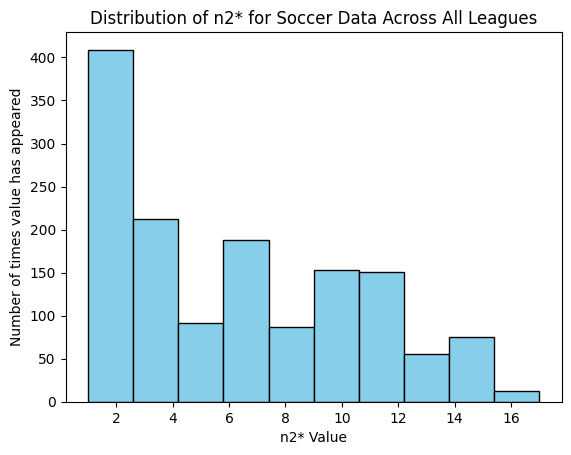

In [11]:
plt.hist(soccer['n2*'],color='skyblue', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('n2* Value')
plt.title('Distribution of n2* for Soccer Data Across All Leagues')
plt.show()

#### Premier League

In [12]:
pl_soccer = soccer[soccer['League']=='Premier_League']
pl_soccer

,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,n1*,c1*,n2*,c2*,normalized_n2*
451,Premier_League,2000,Arsenal,"[0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, ...",28,14,14,20,10,10,1.666866,2.000000,1.555210,1,3.500000,1.0,18.628137,0.035714
452,Premier_League,2000,Aston Villa,"[0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, ...",23,12,11,13,7,6,1.778085,2.339846,1.689189,1,2.300000,1.0,8.206977,0.043478
453,Premier_League,2000,Bradford,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, ...",27,14,13,5,2,3,1.263532,1.385821,1.193317,3,1.848516,3.0,5.247517,0.111111
454,Premier_League,2000,Charlton,"[1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, ...",28,14,14,14,6,8,1.268995,1.290066,1.128668,2,4.000000,2.0,14.063388,0.071429
455,Premier_League,2000,Chelsea,"[1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, ...",28,14,14,17,7,10,1.157062,1.140055,1.067236,4,1.951518,4.0,3.146842,0.142857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
950,Premier_League,2024,Nottm Forest,"[1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1]",13,7,6,9,5,4,1.677028,2.345006,1.488095,6,1.677028,6.0,2.345006,0.461538
951,Premier_League,2024,Southampton,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...",32,16,16,2,1,1,1.358905,2.000000,1.305483,11,2.033836,11.0,6.885488,0.343750
952,Premier_League,2024,Tottenham,"[1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, ...",33,17,16,11,7,4,2.948780,6.162692,3.649635,6,11.390625,6.0,36.028832,0.181818
953,Premier_League,2024,West Ham,"[0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, ...",28,14,14,11,6,5,1.968326,2.862086,1.984127,7,2.295970,7.0,3.978388,0.250000


In [13]:
pl_n2_counts = pl_soccer['n2*'].value_counts().reset_index()
pl_n2_counts

,n2*,count
0,1.0,83
1,2.0,58
2,3.0,49
3,7.0,37
4,5.0,32
5,6.0,32
6,10.0,29
7,8.0,29
8,4.0,28
9,9.0,26


In [14]:
pl_n2_summary = pl_soccer['n2*'].describe().reset_index()
pl_n2_summary

,index,n2*
0,count,502.000000
1,mean,6.179283
2,std,4.332458
3,min,1.000000
4,25%,2.000000
5,50%,6.000000
6,75%,10.000000
7,max,17.000000


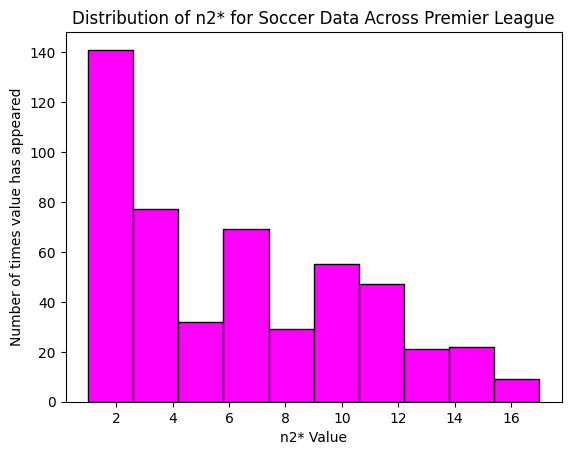

In [15]:
plt.hist(pl_soccer['n2*'],color='magenta', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('n2* Value')
plt.title('Distribution of n2* for Soccer Data Across Premier League')
plt.show()

### La Liga

In [16]:
la_liga_soccer = soccer[soccer['League']=='La_Liga']
la_liga_soccer

,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,n1*,c1*,n2*,c2*,normalized_n2*
955,La_Liga,2000,Alaves,"[1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, ...",31,16,15,14,7,7,1.541379,1.770633,1.420455,5,20.163404,5.0,74.880182,0.161290
956,La_Liga,2000,Ath Bilbao,"[0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, ...",28,14,14,11,7,4,3.355384,8.140033,4.484305,5,12.121198,5.0,42.382306,0.178571
957,La_Liga,2000,Barcelona,"[1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, ...",26,13,13,17,8,9,1.404774,1.515347,1.267427,9,2.621374,9.0,4.510932,0.346154
958,La_Liga,2000,Celta,"[1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, ...",27,14,13,16,5,11,1.011167,1.004908,1.001001,6,1.285244,3.0,1.641785,0.111111
959,La_Liga,2000,Espanol,"[1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, ...",30,15,15,14,6,8,1.279884,1.302265,1.138952,5,4.311495,5.0,10.502532,0.166667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1433,La_Liga,2024,Sociedad,"[0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, ...",31,16,15,13,8,5,2.899686,5.758226,3.367003,6,4.892563,6.0,12.309017,0.193548
1434,La_Liga,2024,Valencia,"[0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, ...",25,13,12,11,3,8,1.031319,1.014335,1.003009,2,3.188776,2.0,10.458316,0.080000
1435,La_Liga,2024,Valladolid,"[1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ...",34,17,17,4,4,0,8.396151,60.167004,19.872814,17,8.396151,17.0,60.167004,0.500000
1436,La_Liga,2024,Vallecano,"[1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",25,13,12,13,7,6,1.793021,2.359879,1.686341,10,3.041173,10.0,6.119959,0.400000


In [17]:
la_liga_n2_counts = la_liga_soccer['n2*'].value_counts().reset_index()
la_liga_n2_counts

,n2*,count
0,1.0,80
1,2.0,60
2,3.0,41
3,6.0,34
4,8.0,33
5,4.0,29
6,5.0,28
7,12.0,28
8,11.0,27
9,9.0,25


In [18]:
la_liga_n2_summary = la_liga_soccer['n2*'].describe().reset_index()
la_liga_n2_summary

,index,n2*
0,count,481.000000
1,mean,6.305613
2,std,4.465160
3,min,1.000000
4,25%,2.000000
5,50%,6.000000
6,75%,10.000000
7,max,17.000000


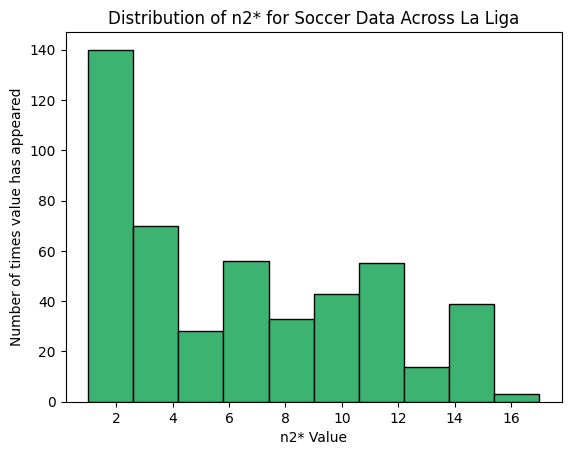

In [19]:
plt.hist(la_liga_soccer['n2*'],color='mediumseagreen', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('n2* Value')
plt.title('Distribution of n2* for Soccer Data Across La Liga')
plt.show()

### Bundesliga

In [20]:
bundesliga_soccer = soccer[soccer['League']=='Bundesliga']
bundesliga_soccer

,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,n1*,c1*,n2*,c2*,normalized_n2*
0,Bundesliga,2000,Bayern Munich,"[1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, ...",28,14,14,19,9,10,1.414208,1.521762,1.233046,10,2.449470,10.0,3.944894,0.357143
1,Bundesliga,2000,Bochum,"[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...",28,14,14,7,5,2,3.557103,10.502532,4.975124,5,4.213992,5.0,12.959781,0.178571
2,Bundesliga,2000,Cottbus,"[0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, ...",31,16,15,12,6,6,1.540103,1.796042,1.443001,13,1.633396,13.0,2.039216,0.419355
3,Bundesliga,2000,Dortmund,"[1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",24,12,12,16,7,9,1.221184,1.239523,1.118568,8,1.880482,5.0,2.768998,0.208333
4,Bundesliga,2000,Ein Frankfurt,"[1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, ...",29,15,14,10,6,4,2.278359,3.863890,2.433090,10,3.663872,10.0,8.551127,0.344828
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
446,Bundesliga,2024,St Pauli,"[0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, ...",26,13,13,8,4,4,1.584677,2.000000,1.497006,9,2.260079,2.0,6.126672,0.076923
447,Bundesliga,2024,Stuttgart,"[0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, ...",26,13,13,14,9,5,4.952094,17.303747,8.415383,13,4.952094,13.0,17.303747,0.500000
448,Bundesliga,2024,Union Berlin,"[1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, ...",23,12,11,10,4,6,1.174159,1.180163,1.090513,8,1.302236,2.0,1.732531,0.086957
449,Bundesliga,2024,Werder Bremen,"[1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, ...",25,13,12,14,7,7,1.491683,1.696854,1.345895,11,1.734933,11.0,2.230477,0.440000


In [21]:
bundesliga_n2_counts = bundesliga_soccer['n2*'].value_counts().reset_index()
bundesliga_n2_counts

,n2*,count
0,1.0,76
1,2.0,52
2,7.0,35
3,4.0,33
4,3.0,32
5,5.0,31
6,9.0,28
7,6.0,28
8,11.0,28
9,10.0,27


In [22]:
bundesliga_n2_summary = bundesliga_soccer['n2*'].describe().reset_index()
bundesliga_n2_summary

,index,n2*
0,count,450.000000
1,mean,6.037778
2,std,4.055395
3,min,1.000000
4,25%,2.000000
5,50%,6.000000
6,75%,9.000000
7,max,15.000000


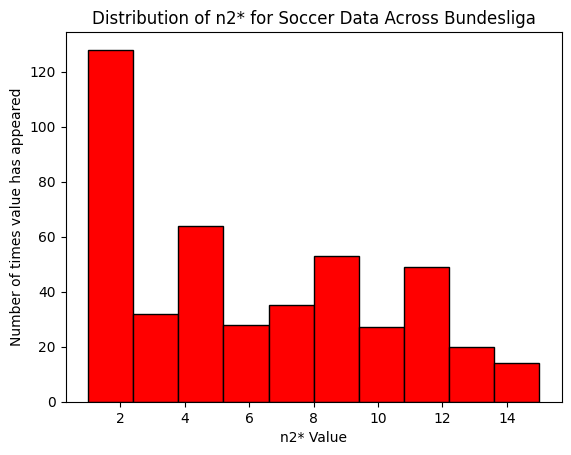

In [23]:
plt.hist(bundesliga_soccer['n2*'],color='red', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('n2* Value')
plt.title('Distribution of n2* for Soccer Data Across Bundesliga')
plt.show()

## Soccer normalized n2* summary statistics

### Overall Leagues

In [24]:
normalized_soccer_n2_counts = soccer['normalized_n2*'].value_counts().reset_index()
normalized_soccer_n2_counts

,normalized_n2*,count
0,0.500000,59
1,0.035714,38
2,0.333333,26
3,0.034483,26
4,0.037037,25
...,...,...
178,0.264706,1
179,0.187500,1
180,0.055556,1
181,0.194444,1


In [25]:
normalized_soccer_n2_summary = soccer['normalized_n2*'].describe().reset_index()
normalized_soccer_n2_summary

,index,normalized_n2*
0,count,1433.000000
1,mean,0.229465
2,std,0.155140
3,min,0.027778
4,25%,0.080000
5,50%,0.206897
6,75%,0.370370
7,max,0.500000


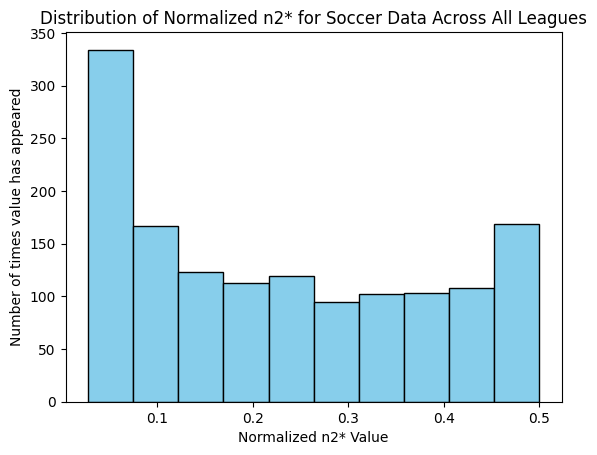

In [26]:
plt.hist(soccer['normalized_n2*'],color='skyblue', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* for Soccer Data Across All Leagues')
plt.show()

### Premier League

In [27]:
pl_normalized_n2_counts = pl_soccer['normalized_n2*'].value_counts().reset_index()
pl_normalized_n2_counts

,normalized_n2*,count
0,0.500000,15
1,0.035714,12
2,0.034483,12
3,0.033333,11
4,0.032258,11
...,...,...
145,0.342857,1
146,0.242424,1
147,0.458333,1
148,0.212121,1


In [28]:
pl_normalized_n2_summary = pl_soccer['normalized_n2*'].describe().reset_index()
pl_normalized_n2_summary

,index,normalized_n2*
0,count,502.000000
1,mean,0.221664
2,std,0.151867
3,min,0.027778
4,25%,0.074074
5,50%,0.200000
6,75%,0.347826
7,max,0.500000


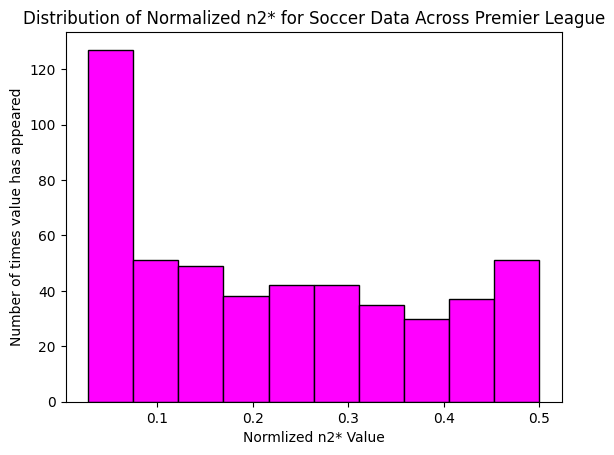

In [29]:
plt.hist(pl_soccer['normalized_n2*'],color='magenta', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normlized n2* Value')
plt.title('Distribution of Normalized n2* for Soccer Data Across Premier League')
plt.show()

### La Liga

In [30]:
la_liga_normalized_n2_counts = la_liga_soccer['normalized_n2*'].value_counts().reset_index()
la_liga_normalized_n2_counts

,normalized_n2*,count
0,0.500000,19
1,0.035714,13
2,0.100000,11
3,0.333333,11
4,0.034483,11
...,...,...
138,0.030303,1
139,0.108108,1
140,0.117647,1
141,0.423077,1


In [31]:
la_liga_normalized_n2_summary = la_liga_soccer['normalized_n2*'].describe().reset_index()
la_liga_normalized_n2_summary

,index,normalized_n2*
0,count,481.000000
1,mean,0.227346
2,std,0.157350
3,min,0.027778
4,25%,0.076923
5,50%,0.200000
6,75%,0.375000
7,max,0.500000


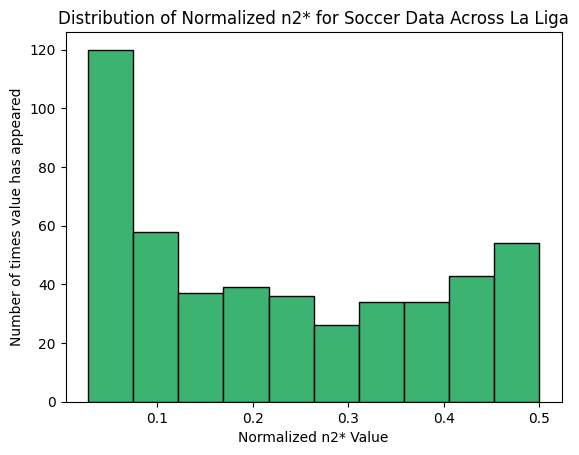

In [32]:
plt.hist(la_liga_soccer['normalized_n2*'],color='mediumseagreen', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* for Soccer Data Across La Liga')
plt.show()

### Bundesliga

In [33]:
bundesliga_normalized_n2_counts = bundesliga_soccer['normalized_n2*'].value_counts().reset_index()
bundesliga_normalized_n2_counts

,normalized_n2*,count
0,0.500000,25
1,0.250000,15
2,0.035714,13
3,0.333333,12
4,0.083333,12
...,...,...
123,0.129032,1
124,0.363636,1
125,0.142857,1
126,0.050000,1


In [34]:
bundesliga_normalized_n2_summary = bundesliga_soccer['normalized_n2*'].describe().reset_index()
bundesliga_normalized_n2_summary

,index,normalized_n2*
0,count,450.000000
1,mean,0.240433
2,std,0.156094
3,min,0.032258
4,25%,0.083333
5,50%,0.230769
6,75%,0.375000
7,max,0.500000


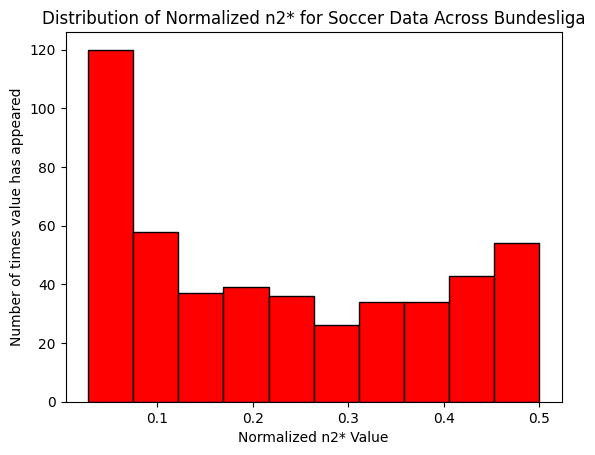

In [35]:
plt.hist(la_liga_soccer['normalized_n2*'],color='red', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* for Soccer Data Across Bundesliga')
plt.show()

# US Leagues 

In [36]:
us_leagues['League'].unique()

array(['NBA', 'MLB'], dtype=object)

In [37]:
us_leagues['normalized_n2*'] = us_leagues['n2*']/us_leagues['n']
us_leagues

,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,n1*,c1*,n2*,c2*,normalized_n2*
0,NBA,2015,Orlando Magic,"[0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, ...",82,41,41,35,20,15,3.764011,7.567749,5.617978,41,3.764011,41,7.567749,0.500000
1,NBA,2015,Houston Rockets,"[0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, ...",82,41,41,41,21,20,2.000000,2.423658,2.057613,35,2.717839,35,3.976260,0.426829
2,NBA,2015,Oklahoma City Thunder,"[1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, ...",82,41,41,55,29,26,2.749747,4.159434,3.300330,8,11.926959,8,32.797102,0.097561
3,NBA,2015,Sacramento Kings,"[0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, ...",82,41,41,33,18,15,2.639310,4.005520,3.105590,39,4.190481,39,8.918303,0.475610
4,NBA,2015,Utah Jazz,"[0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, ...",82,41,41,40,18,22,1.277825,1.232172,1.136364,5,4.923305,2,12.320543,0.024390
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4318,NBA,1982,Indiana Pacers,"[1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, ...",82,41,41,20,13,7,5.464184,16.280440,9.009009,37,12.046809,37,53.259359,0.451220
4319,NBA,1982,Washington Bullets,"[0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, ...",82,41,41,42,18,24,1.158671,1.101917,1.064963,3,2.075934,1,6.610688,0.012195
4320,NBA,1982,Dallas Mavericks,"[1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, ...",82,41,41,38,19,19,1.774389,2.000000,1.808318,11,18.279912,11,45.312997,0.134146
4321,NBA,1982,Denver Nuggets,"[0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, ...",82,41,41,45,19,26,1.115894,1.064008,1.047120,15,1.812723,15,2.236664,0.182927


## N2* Analysis

### Across All Leagues

In [38]:
us_leagues_n2_counts = us_leagues['n2*'].value_counts().reset_index()
us_leagues_n2_counts

,n2*,count
0,1,473
1,2,342
2,3,247
3,4,208
4,5,165
...,...,...
76,62,11
77,51,10
78,64,8
79,60,8


In [39]:
us_leagues_n2_summary = us_leagues['n2*'].describe().reset_index()
us_leagues_n2_summary

,index,n2*
0,count,4323.000000
1,mean,21.942401
2,std,22.439876
3,min,1.000000
4,25%,4.000000
5,50%,13.000000
6,75%,35.000000
7,max,81.000000


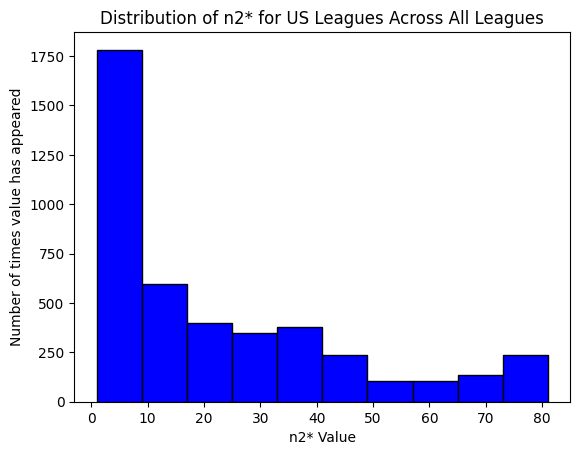

In [40]:
plt.hist(us_leagues['n2*'],color='blue', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('n2* Value')
plt.title('Distribution of n2* for US Leagues Across All Leagues')
plt.show()

### NBA

In [41]:
us_leagues.columns

Index(['League', 'Season', 'Team', 'Sequence', 'n', 'n1', 'n2', 'k', 'k1',
       'k2', 'c1', 'c2', 'c3', 'n1*', 'c1*', 'n2*', 'c2*', 'normalized_n2*'],
      dtype='object')

In [42]:
nba = us_leagues.loc[us_leagues['League'] == 'NBA']
nba['n2*'].value_counts().reset_index()

,n2*,count
0,1,240
1,2,167
2,3,132
3,4,103
4,41,98
5,5,85
6,6,70
7,7,60
8,8,53
9,9,47


In [43]:
nba_n2_summary = nba['n2'].describe().reset_index()
nba_n2_summary

,index,n2
0,count,2017.000000
1,mean,40.554289
2,std,2.773377
3,min,25.000000
4,25%,41.000000
5,50%,41.000000
6,75%,41.000000
7,max,48.000000


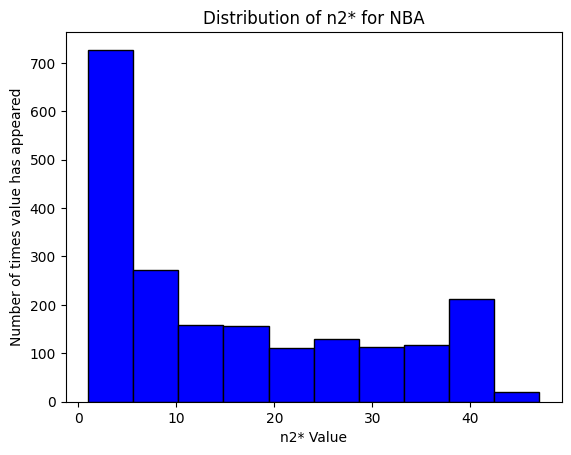

In [44]:
plt.hist(nba['n2*'],color='blue', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('n2* Value')
plt.title('Distribution of n2* for NBA')
plt.show()



### MLB

In [45]:
mlb = us_leagues.loc[us_leagues['League'] == 'MLB']
mlb['n2*'].value_counts().reset_index()

,n2*,count
0,1,233
1,2,175
2,3,115
3,4,105
4,5,80
...,...,...
76,51,10
77,43,8
78,64,8
79,60,8


In [46]:
mlb_n2_summary = mlb['n2'].describe().reset_index()
mlb_n2_summary

,index,n2
0,count,2306.000000
1,mean,78.390286
2,std,7.017386
3,min,29.000000
4,25%,77.000000
5,50%,81.000000
6,75%,81.000000
7,max,82.000000


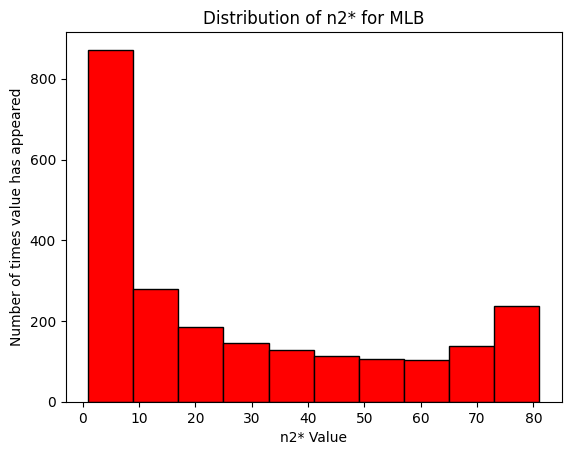

In [47]:
plt.hist(mlb['n2*'],color='red', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('n2* Value')
plt.title('Distribution of n2* for MLB')
plt.show()

## Normalized N2* Analysis

### Across All Leagues

In [48]:
us_leagues['normalized_n2*'].value_counts().reset_index()

,normalized_n2*,count
0,0.500000,176
1,0.012195,175
2,0.006173,146
3,0.024390,126
4,0.012346,102
...,...,...
667,0.190789,1
668,0.105263,1
669,0.138158,1
670,0.118421,1


In [49]:
us_leagues['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,4323.000000
1,mean,0.183212
2,std,0.168713
3,min,0.006135
4,25%,0.031056
5,50%,0.121951
6,75%,0.329268
7,max,0.500000


<function matplotlib.pyplot.show(close=None, block=None)>

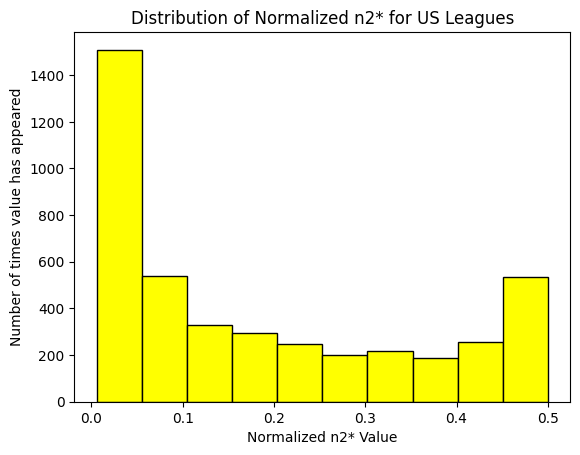

In [50]:
plt.hist(us_leagues['normalized_n2*'],color='yellow', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* for US Leagues')
plt.show

### NBA

In [51]:
nba['normalized_n2*'].value_counts().reset_index()

,normalized_n2*,count
0,0.012195,175
1,0.024390,126
2,0.500000,116
3,0.036585,89
4,0.048780,74
...,...,...
232,0.472222,1
233,0.136364,1
234,0.015385,1
235,0.126761,1


In [52]:
nba['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,2017.000000
1,mean,0.191826
2,std,0.168418
3,min,0.010638
4,25%,0.036585
5,50%,0.134146
6,75%,0.341463
7,max,0.500000


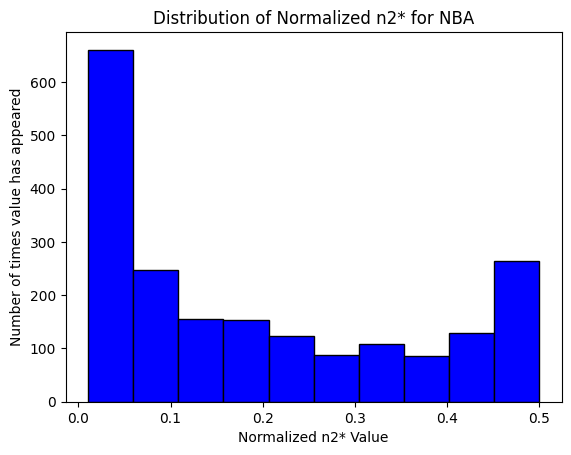

In [53]:
plt.hist(nba['normalized_n2*'],color='blue', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* for NBA')
plt.show()

### MLB

In [54]:
mlb['normalized_n2*'].value_counts().reset_index()

,normalized_n2*,count
0,0.006173,146
1,0.012346,100
2,0.018519,74
3,0.500000,60
4,0.024691,60
...,...,...
476,0.493056,1
477,0.229167,1
478,0.354037,1
479,0.136646,1


In [55]:
mlb['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,2306.000000
1,mean,0.175678
2,std,0.168646
3,min,0.006135
4,25%,0.024730
5,50%,0.104938
6,75%,0.320988
7,max,0.500000


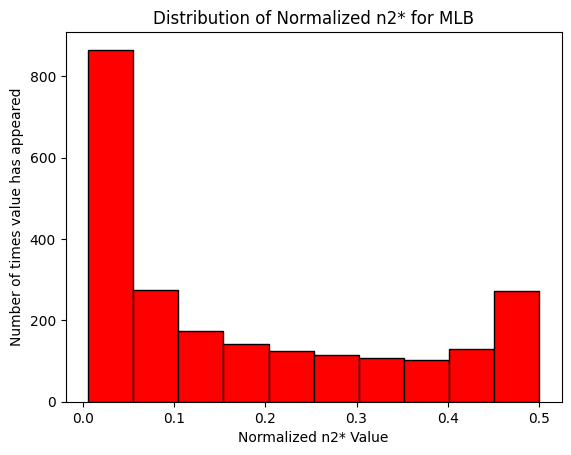

In [56]:
plt.hist(mlb['normalized_n2*'],color='red', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* for MLB')
plt.show()

In [57]:
combined = pd.concat([soccer, us_leagues], ignore_index=True)

In [58]:
combined['normalized_n2*'].value_counts().reset_index()

,normalized_n2*,count
0,0.500000,235
1,0.012195,175
2,0.006173,146
3,0.024390,126
4,0.012346,102
...,...,...
748,0.150327,1
749,0.146497,1
750,0.012739,1
751,0.366013,1


In [59]:
combined['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,5756.000000
1,mean,0.194727
2,std,0.166629
3,min,0.006135
4,25%,0.040000
5,50%,0.146018
6,75%,0.341463
7,max,0.500000


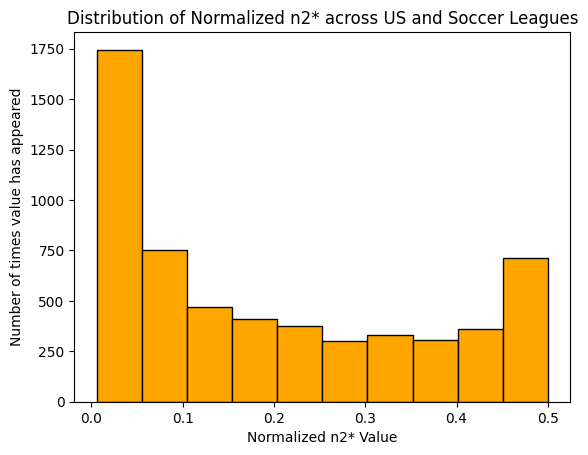

In [60]:
plt.hist(combined['normalized_n2*'],color='orange', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* across US and Soccer Leagues')
plt.show()

# Normalized N2 for top 100 c2 scores

## Soccer

In [61]:
soccer_top100_c2 = soccer.nlargest(100, 'c2').reset_index(drop=True)
soccer_top100_c2

,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,n1*,c1*,n2*,c2*,normalized_n2*
0,Bundesliga,2019,Schalke 04,"[0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, ...",22,11,11,9,8,1,37.844079,832.591030,259.067358,10,192.660767,10.0,5447.173990,0.454545
1,La_Liga,2015,Eibar,"[1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, ...",28,14,14,11,9,2,22.451665,296.062527,103.305785,14,22.451665,14.0,296.062527,0.500000
2,Bundesliga,2016,Ein Frankfurt,"[1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, ...",25,13,12,11,9,2,20.544653,244.981845,90.009001,11,61.055666,11.0,1094.247411,0.440000
3,Bundesliga,2009,Leverkusen,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, ...",20,10,10,15,10,5,12.799688,203.598097,62.500000,7,77.649289,7.0,4611.101344,0.350000
4,La_Liga,2009,La Coruna,"[0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, ...",30,15,15,13,10,3,18.074803,201.882086,79.239303,10,33.873098,10.0,217.848067,0.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,La_Liga,2014,Malaga,"[1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, ...",30,15,15,14,9,5,4.542665,13.963077,7.366483,8,19.095023,8.0,84.399193,0.266667
96,La_Liga,2008,Barcelona,"[0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",32,16,16,27,15,12,4.304088,13.876647,5.780347,2,40.960000,2.0,2904.807020,0.062500
97,La_Liga,2013,Barcelona,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, ...",32,16,16,27,15,12,4.304088,13.876647,6.250000,14,6.114165,14.0,26.572173,0.437500
98,Premier_League,2017,Man City,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",34,17,17,32,17,15,3.786036,13.801405,4.219409,14,5.060975,14.0,24.554732,0.411765


In [62]:
soccer_top100_c2['normalized_n2*'].value_counts().reset_index()

,normalized_n2*,count
0,0.500000,19
1,0.482759,4
2,0.444444,4
3,0.483871,4
4,0.464286,3
5,0.481481,3
6,0.437500,2
7,0.478261,2
8,0.333333,2
9,0.440000,2


In [63]:
soccer_top100_c2['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,100.000000
1,mean,0.379236
2,std,0.131529
3,min,0.062500
4,25%,0.297917
5,50%,0.438750
6,75%,0.482759
7,max,0.500000


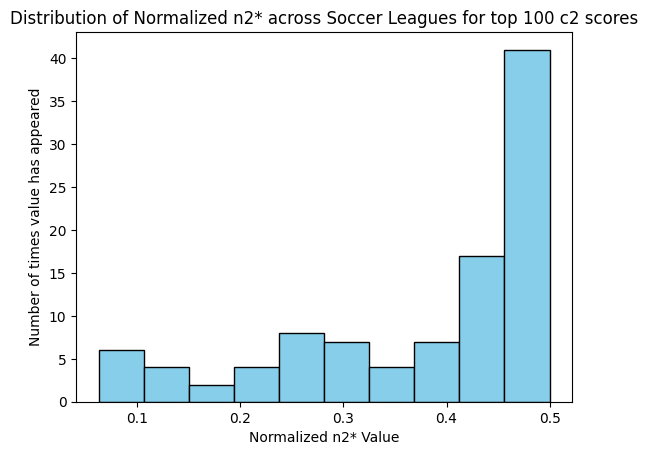

In [64]:
plt.hist(soccer_top100_c2['normalized_n2*'],color='skyblue', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* across Soccer Leagues for top 100 c2 scores')
plt.show()

### Premier League

In [65]:
PL_top100_c2 = pl_soccer.nlargest(100, 'c2').reset_index(drop=True)

In [66]:
PL_top100_c2['normalized_n2*'].value_counts().reset_index()

,normalized_n2*,count
0,0.500000,8
1,0.483871,4
2,0.310345,3
3,0.464286,3
4,0.360000,3
...,...,...
64,0.375000,1
65,0.193548,1
66,0.166667,1
67,0.028571,1


In [67]:
PL_top100_c2['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,100.000000
1,mean,0.327327
2,std,0.141043
3,min,0.028571
4,25%,0.220238
5,50%,0.352484
6,75%,0.454094
7,max,0.500000


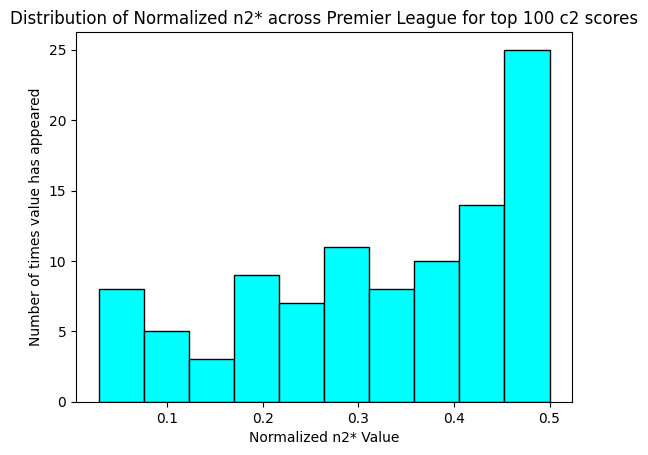

In [68]:
plt.hist(PL_top100_c2['normalized_n2*'],color='Aqua', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* across Premier League for top 100 c2 scores')
plt.show()

### La Liga

In [69]:
LaLiga_top100_c2 = la_liga_soccer.nlargest(100, 'c2').reset_index(drop=True)

In [70]:
LaLiga_top100_c2['normalized_n2*'].value_counts().reset_index()

,normalized_n2*,count
0,0.500000,11
1,0.464286,5
2,0.483871,4
3,0.482759,3
4,0.200000,3
5,0.321429,3
6,0.413793,3
7,0.100000,3
8,0.222222,3
9,0.259259,2


In [71]:
LaLiga_top100_c2['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,100.000000
1,mean,0.328930
2,std,0.155801
3,min,0.031250
4,25%,0.200000
5,50%,0.403704
6,75%,0.466667
7,max,0.500000


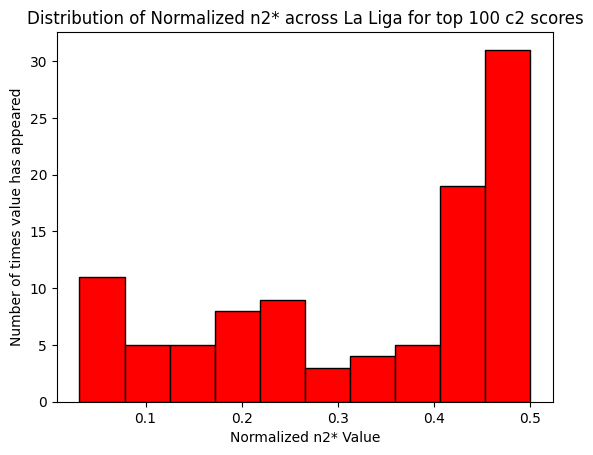

In [72]:
plt.hist(LaLiga_top100_c2['normalized_n2*'],color='Red', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* across La Liga for top 100 c2 scores')
plt.show()

### Bundesliga

In [73]:
Bundesliga_top100_c2 = bundesliga_soccer.nlargest(100, 'c2').reset_index(drop=True)

In [74]:
Bundesliga_top100_c2['normalized_n2*'].value_counts().reset_index()

,normalized_n2*,count
0,0.500000,11
1,0.480000,6
2,0.250000,4
3,0.333333,3
4,0.473684,3
...,...,...
58,0.466667,1
59,0.428571,1
60,0.166667,1
61,0.125000,1


In [75]:
Bundesliga_top100_c2['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,100.000000
1,mean,0.341418
2,std,0.137489
3,min,0.037037
4,25%,0.241034
5,50%,0.372685
6,75%,0.468421
7,max,0.500000


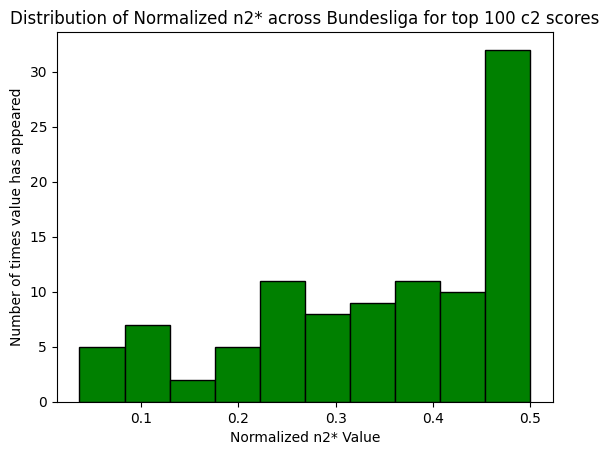

In [76]:
plt.hist(Bundesliga_top100_c2['normalized_n2*'],color='Green', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* across Bundesliga for top 100 c2 scores')
plt.show()

# US Leagues

In [77]:
us_leagues_top100_c2 = us_leagues.nlargest(100, 'c2').reset_index(drop=True)

In [78]:
us_leagues_top100_c2['normalized_n2*'].value_counts().reset_index()

,normalized_n2*,count
0,0.500000,19
1,0.487805,5
2,0.475309,4
3,0.487654,3
4,0.402439,2
...,...,...
56,0.243902,1
57,0.310559,1
58,0.024390,1
59,0.250000,1


In [79]:
us_leagues_top100_c2['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,100.000000
1,mean,0.406226
2,std,0.112153
3,min,0.024390
4,25%,0.353395
5,50%,0.457153
6,75%,0.488403
7,max,0.500000


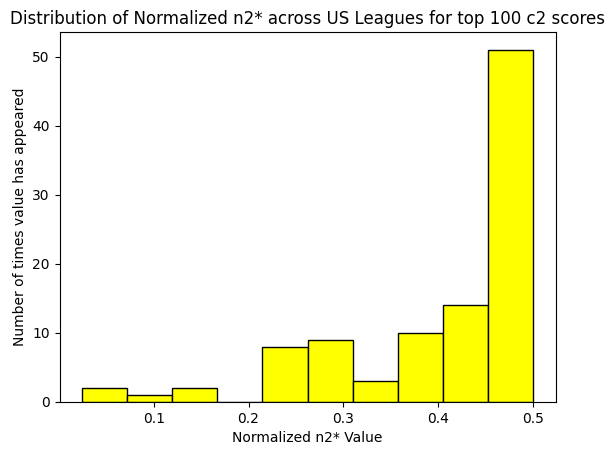

In [80]:
plt.hist(us_leagues_top100_c2['normalized_n2*'],color='Yellow', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* across US Leagues for top 100 c2 scores')
plt.show()

### MLB

In [81]:
mlb_top100_c2 = mlb.nlargest(100, 'c2').reset_index(drop=True)

In [82]:
mlb_top100_c2['normalized_n2*'].value_counts().reset_index()

,normalized_n2*,count
0,0.500000,16
1,0.487654,5
2,0.475309,4
3,0.493827,2
4,0.490683,2
...,...,...
62,0.411765,1
63,0.354037,1
64,0.409722,1
65,0.478261,1


In [83]:
mlb_top100_c2['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,100.000000
1,mean,0.391120
2,std,0.128334
3,min,0.024691
4,25%,0.323010
5,50%,0.452017
6,75%,0.488290
7,max,0.500000


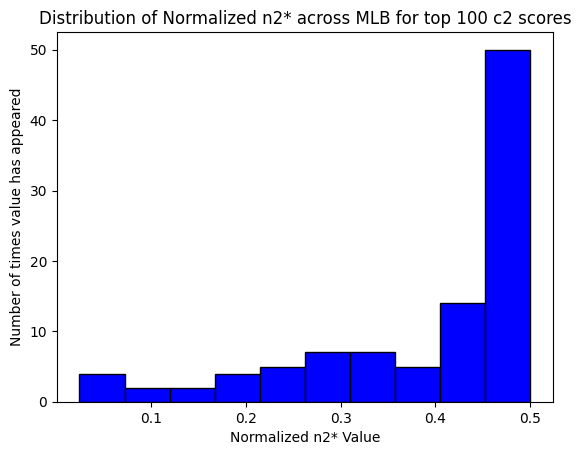

In [84]:
plt.hist(mlb_top100_c2['normalized_n2*'],color='blue', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* across MLB for top 100 c2 scores')
plt.show()

### NBA

In [85]:
nba_top100_c2 = nba.nlargest(100, 'c2').reset_index(drop=True)

In [86]:
nba_top100_c2['normalized_n2*'].value_counts().reset_index()

,normalized_n2*,count
0,0.500000,25
1,0.487805,6
2,0.402439,4
3,0.256098,4
4,0.097561,3
5,0.451220,3
6,0.439024,3
7,0.268293,3
8,0.463415,3
9,0.365854,2


In [87]:
nba_top100_c2['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,100.000000
1,mean,0.393408
2,std,0.127116
3,min,0.024390
4,25%,0.347436
5,50%,0.446784
6,75%,0.490854
7,max,0.500000


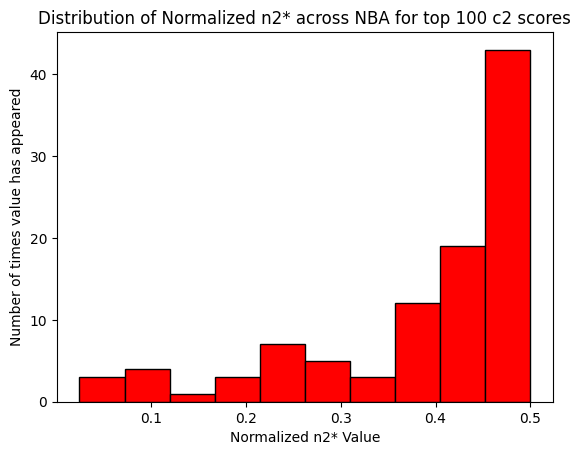

In [88]:
plt.hist(nba_top100_c2['normalized_n2*'],color='red', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* across NBA for top 100 c2 scores')
plt.show()

# Combined

In [89]:
top100_c2 = combined.nlargest(100, 'c2').reset_index(drop=True)

In [90]:
top100_c2

,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,n1*,c1*,n2*,c2*,normalized_n2*
0,NBA,2010,Utah Jazz,"[0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, ...",82,41,41,39,27,12,75.132853,2197.222917,1063.829787,41,75.132853,41.0,2197.222917,0.500000
1,MLB,1977,Chicago Cubs,"[0,0,1,1,1,1,0,0,0,0,1,1,1,0,0,0,1,1,0,1,1,1,1...",162,81,81,81,51,30,77.959464,2067.336349,1333.333333,39,211.075016,63.0,2804.288740,0.388889
2,MLB,1943,Philadelphia Athletics,"[0,0,1,1,0,0,1,0,0,0,0,1,1,0,1,0,1,0,1,0,1,1,0...",154,77,77,49,34,15,87.788091,1976.242593,1204.819277,56,162.387796,77.0,1976.242593,0.500000
3,MLB,1949,Washington Senators,"[1,0,0,0,0,0,0,0,1,0,0,1,0,0,1,1,1,1,1,1,1,1,1...",154,77,77,50,34,16,60.154303,1025.288429,613.496933,77,60.154303,77.0,1025.288429,0.500000
4,Bundesliga,2019,Schalke 04,"[0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, ...",22,11,11,9,8,1,37.844079,832.591030,259.067358,10,192.660767,10.0,5447.173990,0.454545
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,NBA,1994,Orlando Magic,"[0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, ...",82,41,41,57,33,24,11.146195,64.820849,38.402458,20,51.540862,20.0,324.055403,0.243902
96,NBA,1993,Philadelphia 76ers,"[1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, ...",82,41,41,25,17,8,11.953933,64.820849,37.537538,36,53.664914,36.0,516.607590,0.439024
97,NBA,1980,Philadelphia 76ers,"[0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",95,48,47,70,40,30,11.309670,64.726863,34.482759,36,30.683089,36.0,251.542607,0.378947
98,NBA,1980,Philadelphia 76ers,"[0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",95,48,47,70,40,30,11.309670,64.726863,32.258065,36,30.683089,36.0,251.542607,0.378947


In [91]:
top100_c2['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,100.000000
1,mean,0.411629
2,std,0.104063
3,min,0.055556
4,25%,0.358528
5,50%,0.455668
6,75%,0.488403
7,max,0.500000


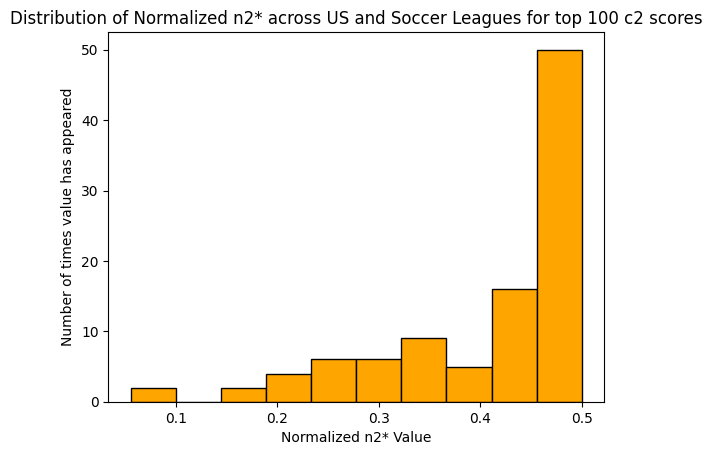

In [92]:
plt.hist(top100_c2['normalized_n2*'],color='orange', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* across US and Soccer Leagues for top 100 c2 scores')
plt.show()

# Normalized N2 for top 20 c2 scores

## Soccer

In [102]:
soccer_top20_c2 = soccer.nlargest(20, 'c2').reset_index(drop=True)
soccer_top20_c2

,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,n1*,c1*,n2*,c2*,normalized_n2*
0,Bundesliga,2019,Schalke 04,"[0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, ...",22,11,11,9,8,1,37.844079,832.591030,259.067358,10,192.660767,10.0,5447.173990,0.454545
1,La_Liga,2015,Eibar,"[1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, ...",28,14,14,11,9,2,22.451665,296.062527,103.305785,14,22.451665,14.0,296.062527,0.500000
2,Bundesliga,2016,Ein Frankfurt,"[1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, ...",25,13,12,11,9,2,20.544653,244.981845,90.009001,11,61.055666,11.0,1094.247411,0.440000
3,Bundesliga,2009,Leverkusen,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, ...",20,10,10,15,10,5,12.799688,203.598097,62.500000,7,77.649289,7.0,4611.101344,0.350000
4,La_Liga,2009,La Coruna,"[0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, ...",30,15,15,13,10,3,18.074803,201.882086,79.239303,10,33.873098,10.0,217.848067,0.333333
5,Premier_League,2015,Crystal Palace,"[1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, ...",29,15,14,11,9,2,18.233383,178.009391,70.472163,14,18.233383,14.0,178.009391,0.482759
6,La_Liga,2021,Vallecano,"[0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, ...",29,15,14,11,9,2,18.233383,178.009391,69.979006,14,18.233383,14.0,178.009391,0.482759
7,La_Liga,2007,Espanol,"[0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, ...",29,15,14,13,10,3,15.426215,139.160090,53.676865,7,64.260797,13.0,493.160072,0.448276
8,Premier_League,2020,Southampton,"[1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, ...",34,17,17,15,11,4,14.565527,128.074395,53.504548,17,14.565527,17.0,128.074395,0.500000
9,Premier_League,2008,Hull,"[1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, ...",27,14,13,8,7,1,14.886089,123.854630,46.904315,13,14.886089,13.0,123.854630,0.481481


In [103]:
soccer_top20_c2['normalized_n2*'].value_counts().reset_index()

,normalized_n2*,count
0,0.500000,3
1,0.482759,2
2,0.333333,2
3,0.481481,2
4,0.440000,1
5,0.350000,1
6,0.454545,1
7,0.448276,1
8,0.444444,1
9,0.407407,1


In [95]:
soccer_top20_c2['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,20.000000
1,mean,0.441282
2,std,0.061073
3,min,0.312500
4,25%,0.429977
5,50%,0.464115
6,75%,0.482759
7,max,0.500000


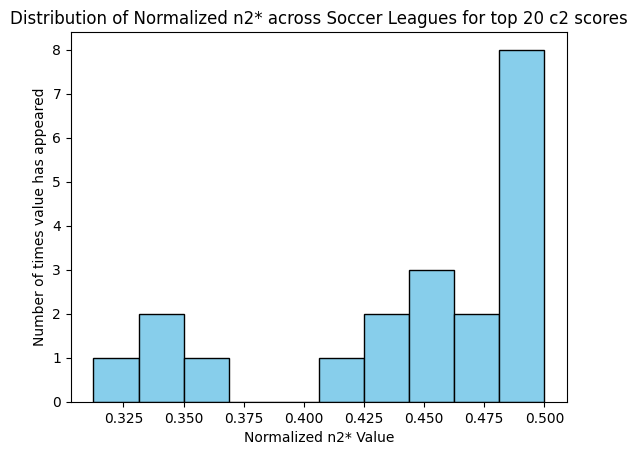

In [105]:
plt.hist(soccer_top20_c2['normalized_n2*'],color='skyblue', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* across Soccer Leagues for top 20 c2 scores')
plt.show()

### Premier League

In [107]:
PL_top20_c2 = pl_soccer.nlargest(20, 'c2').reset_index(drop=True)

In [108]:
PL_top20_c2['normalized_n2*'].value_counts().reset_index()

,normalized_n2*,count
0,0.500000,5
1,0.481481,2
2,0.444444,2
3,0.483871,2
4,0.416667,2
5,0.482759,1
6,0.312500,1
7,0.407407,1
8,0.464286,1
9,0.093750,1


In [109]:
PL_top20_c2['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,20.000000
1,mean,0.421335
2,std,0.109376
3,min,0.093750
4,25%,0.414352
5,50%,0.472884
6,75%,0.487903
7,max,0.500000


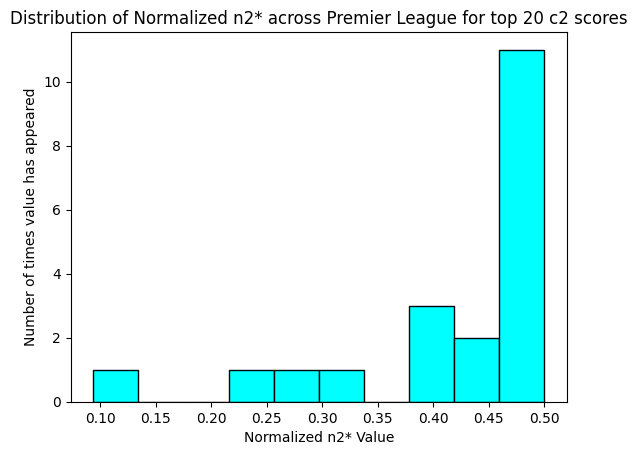

In [110]:
plt.hist(PL_top20_c2['normalized_n2*'],color='Aqua', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* across Premier League for top 20 c2 scores')
plt.show()

### La Liga

In [111]:
LaLiga_top20_c2 = la_liga_soccer.nlargest(20, 'c2').reset_index(drop=True)

In [112]:
LaLiga_top20_c2['normalized_n2*'].value_counts().reset_index()

,normalized_n2*,count
0,0.500000,6
1,0.482759,2
2,0.333333,1
3,0.448276,1
4,0.437500,1
5,0.478261,1
6,0.064516,1
7,0.260870,1
8,0.483871,1
9,0.117647,1


In [113]:
LaLiga_top20_c2['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,20.000000
1,mean,0.394141
2,std,0.148250
3,min,0.064516
4,25%,0.315217
5,50%,0.479871
6,75%,0.500000
7,max,0.500000


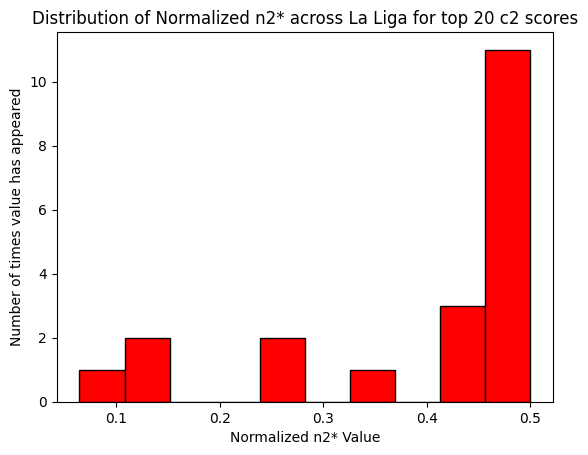

In [114]:
plt.hist(LaLiga_top20_c2['normalized_n2*'],color='Red', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* across La Liga for top 20 c2 scores')
plt.show()

### Bundesliga

In [117]:
Bundesliga_top20_c2 = bundesliga_soccer.nlargest(20, 'c2').reset_index(drop=True)

In [118]:
Bundesliga_top20_c2['normalized_n2*'].value_counts().reset_index()

,normalized_n2*,count
0,0.500000,3
1,0.454545,1
2,0.440000,1
3,0.350000,1
4,0.333333,1
5,0.473684,1
6,0.307692,1
7,0.476190,1
8,0.444444,1
9,0.240000,1


In [119]:
Bundesliga_top20_c2['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,20.000000
1,mean,0.393169
2,std,0.095835
3,min,0.222222
4,25%,0.315559
5,50%,0.429677
6,75%,0.477143
7,max,0.500000


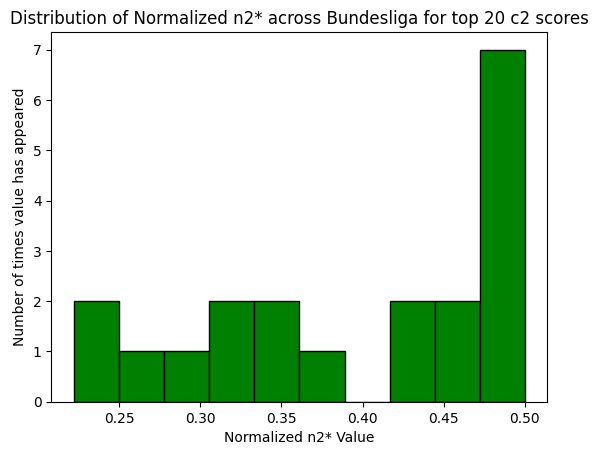

In [120]:
plt.hist(Bundesliga_top20_c2['normalized_n2*'],color='Green', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* across Bundesliga for top 20 c2 scores')
plt.show()

# US Leagues

In [122]:
us_leagues_top20_c2 = us_leagues.nlargest(20, 'c2').reset_index(drop=True)

In [123]:
us_leagues_top20_c2['normalized_n2*'].value_counts().reset_index()

,normalized_n2*,count
0,0.500000,4
1,0.402439,2
2,0.459770,2
3,0.231707,2
4,0.388889,1
5,0.487654,1
6,0.472050,1
7,0.490683,1
8,0.462963,1
9,0.467532,1


In [124]:
us_leagues_top20_c2['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,20.000000
1,mean,0.425826
2,std,0.086824
3,min,0.231707
4,25%,0.399051
5,50%,0.461367
6,75%,0.488412
7,max,0.500000


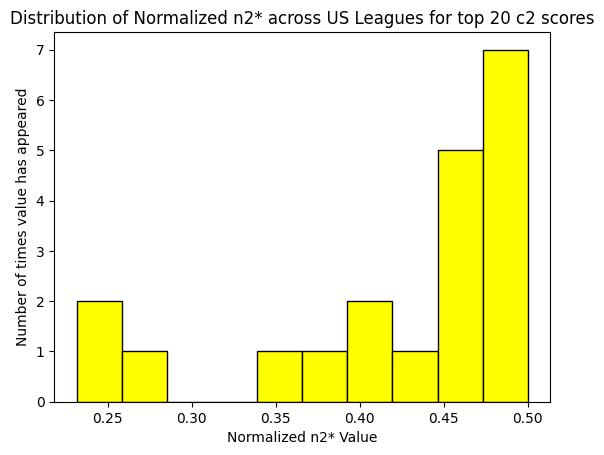

In [125]:
plt.hist(us_leagues_top20_c2['normalized_n2*'],color='Yellow', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* across US Leagues for top 20 c2 scores')
plt.show()

### MLB

In [126]:
mlb_top20_c2 = mlb.nlargest(20, 'c2').reset_index(drop=True)

In [127]:
mlb_top20_c2['normalized_n2*'].value_counts().reset_index()

,normalized_n2*,count
0,0.500000,3
1,0.487654,2
2,0.475309,2
3,0.388889,1
4,0.472050,1
5,0.462963,1
6,0.467532,1
7,0.490683,1
8,0.481481,1
9,0.283951,1


In [128]:
mlb_top20_c2['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,20.000000
1,mean,0.442049
2,std,0.082904
3,min,0.229814
4,25%,0.455918
5,50%,0.474667
6,75%,0.488412
7,max,0.500000


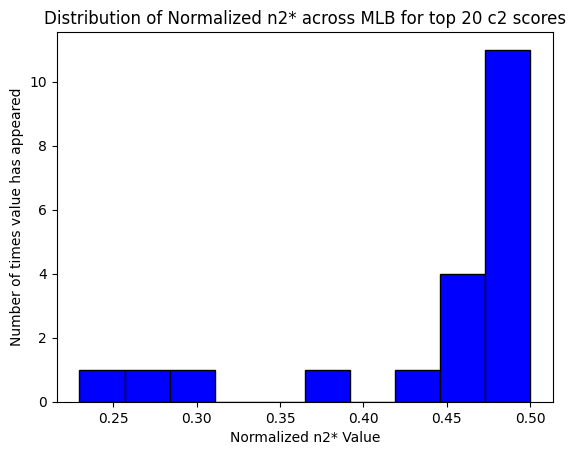

In [129]:
plt.hist(mlb_top20_c2['normalized_n2*'],color='blue', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* across MLB for top 20 c2 scores')
plt.show()

### NBA

In [131]:
nba_top20_c2 = nba.nlargest(20, 'c2').reset_index(drop=True)

In [132]:
nba_top20_c2['normalized_n2*'].value_counts().reset_index()

,normalized_n2*,count
0,0.500000,6
1,0.402439,2
2,0.231707,2
3,0.459770,2
4,0.358696,2
5,0.365854,1
6,0.487805,1
7,0.268293,1
8,0.304878,1
9,0.280488,1


In [133]:
nba_top20_c2['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,20.000000
1,mean,0.403188
2,std,0.097113
3,min,0.231707
4,25%,0.345241
5,50%,0.426829
6,75%,0.500000
7,max,0.500000


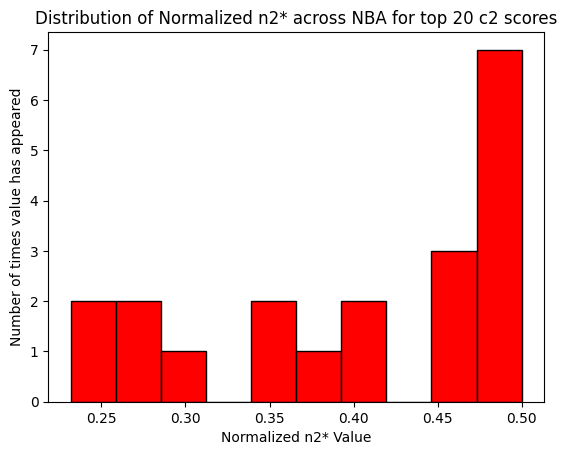

In [134]:
plt.hist(nba_top20_c2['normalized_n2*'],color='red', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* across NBA for top 20 c2 scores')
plt.show()

# Combined

In [137]:
top20_c2 = combined.nlargest(20, 'c2').reset_index(drop=True)

In [138]:
top20_c2

,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,n1*,c1*,n2*,c2*,normalized_n2*
0,NBA,2010,Utah Jazz,"[0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, ...",82,41,41,39,27,12,75.132853,2197.222917,1063.829787,41,75.132853,41.0,2197.222917,0.500000
1,MLB,1977,Chicago Cubs,"[0,0,1,1,1,1,0,0,0,0,1,1,1,0,0,0,1,1,0,1,1,1,1...",162,81,81,81,51,30,77.959464,2067.336349,1333.333333,39,211.075016,63.0,2804.288740,0.388889
2,MLB,1943,Philadelphia Athletics,"[0,0,1,1,0,0,1,0,0,0,0,1,1,0,1,0,1,0,1,0,1,1,0...",154,77,77,49,34,15,87.788091,1976.242593,1204.819277,56,162.387796,77.0,1976.242593,0.500000
3,MLB,1949,Washington Senators,"[1,0,0,0,0,0,0,0,1,0,0,1,0,0,1,1,1,1,1,1,1,1,1...",154,77,77,50,34,16,60.154303,1025.288429,613.496933,77,60.154303,77.0,1025.288429,0.500000
4,Bundesliga,2019,Schalke 04,"[0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, ...",22,11,11,9,8,1,37.844079,832.591030,259.067358,10,192.660767,10.0,5447.173990,0.454545
5,NBA,1975,Atlanta Hawks,"[1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, ...",82,41,41,29,21,8,46.612073,747.418894,396.825397,18,237.843734,33.0,1191.795039,0.402439
6,NBA,1975,Atlanta Hawks,"[1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, ...",82,41,41,29,21,8,46.612073,747.418894,438.596491,18,237.843734,33.0,1191.795039,0.402439
7,MLB,2005,Washington Nationals,"[0,1,1,0,1,0,0,1,1,1,1,1,0,0,1,0,0,0,1,0,1,0,1...",162,81,81,81,50,31,44.614453,706.569512,458.715596,79,47.432205,79.0,708.676432,0.487654
8,MLB,2004,Milwaukee Brewers,"[1,1,0,1,0,1,0,0,0,1,1,0,0,0,1,1,0,1,1,0,1,1,0...",161,81,80,67,43,24,46.172222,674.579053,427.350427,71,74.790997,79.0,1261.399061,0.490683
9,MLB,1973,Chicago Cubs,"[1,1,0,0,0,1,1,1,1,0,1,1,0,1,0,0,0,1,1,1,1,0,1...",161,81,80,77,48,29,41.097926,575.527675,362.318841,76,48.866012,76.0,638.114110,0.472050


In [139]:
top20_c2['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,20.000000
1,mean,0.433879
2,std,0.086959
3,min,0.231707
4,25%,0.402439
5,50%,0.465248
6,75%,0.493012
7,max,0.500000


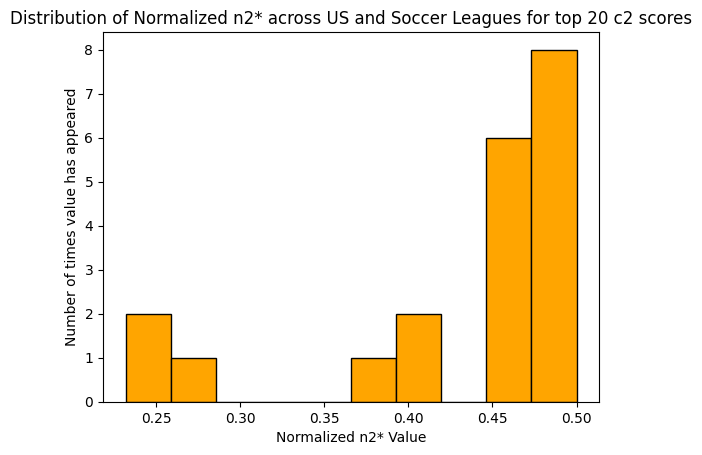

In [140]:
plt.hist(top20_c2['normalized_n2*'],color='orange', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* across US and Soccer Leagues for top 20 c2 scores')
plt.show()